In [27]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv("reviews.csv")
df.shape

(10000, 8)

In [28]:
df.columns

Index(['Restaurant', 'Reviewer', 'Review', 'Rating', 'Metadata', 'Time',
       'Pictures', '7514'],
      dtype='object')

In [29]:
from collections import Counter
Counter( df['Rating'])

Counter({'5': 3832,
         '4': 2373,
         '1': 1735,
         '3': 1193,
         '2': 684,
         '4.5': 69,
         '3.5': 47,
         nan: 38,
         '2.5': 19,
         '1.5': 9,
         'Like': 1})

In [30]:
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords', quiet=True)
stop_words = set(stopwords.words('english'))

def clean(text):
    if pd.isna(text):
        return ""
    text = str(text)
    text = re.sub(r'[^a-zA-Z\s]', '', text, re.I|re.A)
    text = text.lower()
    
    text = ' '.join([word for word in text.split() if word not in stop_words])
    return text

df['Cleaned'] = df['Review'].apply(clean)

df = df[df['Cleaned'] != ""]

print(df['Cleaned'].head())
print(f"Рядків після філіьтрації --->{len(df)}")

0    ambience good food quite good saturday lunch c...
1    ambience good pleasant evening service prompt ...
2    must try great food great ambience thnx servic...
3    soumen das arun great guy behavior sincerety g...
4    food goodwe ordered kodi drumsticks basket mut...
Name: Cleaned, dtype: object
Рядків після філіьтрації --->9931


In [31]:
rating_map = {
    '4.5': '5',
    '3.5': '4',
    '2.5': '3',
    '1.5': '2'
}

# я вирішив видалити строку з значенням Like а також рейтинги типу 4,5 привести до вигляду 5, а 3,5 до 4 і тдю
df = df[df['Rating'] != 'Like']

df['Rating'] = df['Rating'].astype(str).replace(rating_map).astype(float)

from collections import Counter
Counter( df['Rating'])


Counter({5.0: 3880, 4.0: 2418, 1.0: 1731, 3.0: 1209, 2.0: 692})

In [32]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

X = df['Review']
y = df['Rating']

tokenizer = Tokenizer()
tokenizer.fit_on_texts(X)
X_seq = tokenizer.texts_to_sequences(X)

X_pad = pad_sequences(X_seq, padding='post')

X_train, X_test, y_train, y_test = train_test_split(X_pad, y, test_size=0.2, random_state=42)

In [53]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

vocab_size = len(tokenizer.word_index) + 1  

model_pretrained = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, trainable=False),
    LSTM(64, return_sequences=True),
    Dropout(0.5),
    LSTM(64),
    Dense(32, activation='relu'),
    Dropout(0.5),
    Dense(6, activation='softmax')
])
history_scratch = model_scratch.fit(X_train, y_train, epochs=5, batch_size=32, validation_data=(X_test, y_test))


Epoch 1/5
249/249 ━━━━━━━━━━━━━━━━━━━━ 70s 282ms/step - accuracy: 0.3839 - loss: 1.4729 - val_accuracy: 0.4038 - val_loss: 1.4524
Epoch 2/5
249/249 ━━━━━━━━━━━━━━━━━━━━ 77s 310ms/step - accuracy: 0.3847 - loss: 1.4726 - val_accuracy: 0.4038 - val_loss: 1.4494
Epoch 3/5
249/249 ━━━━━━━━━━━━━━━━━━━━ 77s 309ms/step - accuracy: 0.3884 - loss: 1.4636 - val_accuracy: 0.4038 - val_loss: 1.4491
Epoch 4/5
249/249 ━━━━━━━━━━━━━━━━━━━━ 75s 300ms/step - accuracy: 0.3867 - loss: 1.4705 - val_accuracy: 0.4038 - val_loss: 1.4515
Epoch 5/5
249/249 ━━━━━━━━━━━━━━━━━━━━ 76s 304ms/step - accuracy: 0.3847 - loss: 1.4662 - val_accuracy: 0.4038 - val_loss: 1.4505


In [54]:

embedding_dim = 100
glove_file = './glove.6B.100d.txt'  
embeddings_index = {}

with open(glove_file, 'r', encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = coefs

embedding_matrix = np.zeros((vocab_size, embedding_dim))

for word, i in tokenizer.word_index.items():
    if i < vocab_size:
        embedding_vector = embeddings_index.get(word)
        if embedding_vector is not None:
            embedding_matrix[i] = embedding_vector


model_pretrained = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, weights=[embedding_matrix], trainable=False),
    LSTM(64, return_sequences=True),
    Dropout(0.5),
    LSTM(64),
    Dense(32, activation='relu'),
    Dropout(0.5),
    Dense(6, activation='softmax')
])
model_pretrained.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history_pretrained = model_pretrained.fit(X_train, y_train, epochs=5, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/5
249/249 ━━━━━━━━━━━━━━━━━━━━ 316s 1s/step - accuracy: 0.3281 - loss: 1.6153 - val_accuracy: 0.4033 - val_loss: 1.4836
Epoch 2/5
249/249 ━━━━━━━━━━━━━━━━━━━━ 237s 951ms/step - accuracy: 0.3705 - loss: 1.5267 - val_accuracy: 0.4033 - val_loss: 1.4522
Epoch 3/5
249/249 ━━━━━━━━━━━━━━━━━━━━ 258s 1s/step - accuracy: 0.3979 - loss: 1.4821 - val_accuracy: 0.4033 - val_loss: 1.4528
Epoch 4/5
249/249 ━━━━━━━━━━━━━━━━━━━━ 260s 1s/step - accuracy: 0.3922 - loss: 1.4861 - val_accuracy: 0.4033 - val_loss: 1.4529
Epoch 5/5
249/249 ━━━━━━━━━━━━━━━━━━━━ 424s 2s/step - accuracy: 0.3905 - loss: 1.4776 - val_accuracy: 0.4033 - val_loss: 1.4529


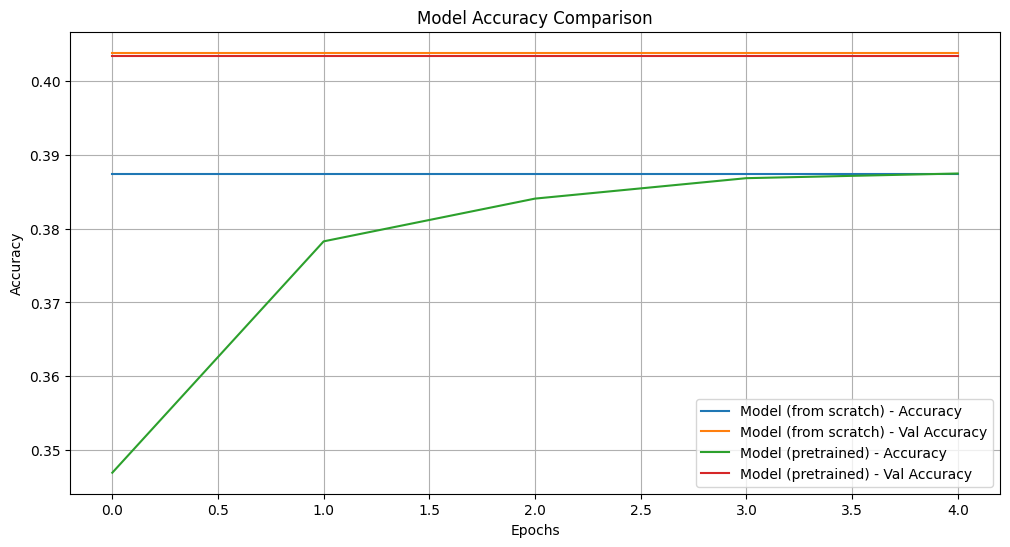

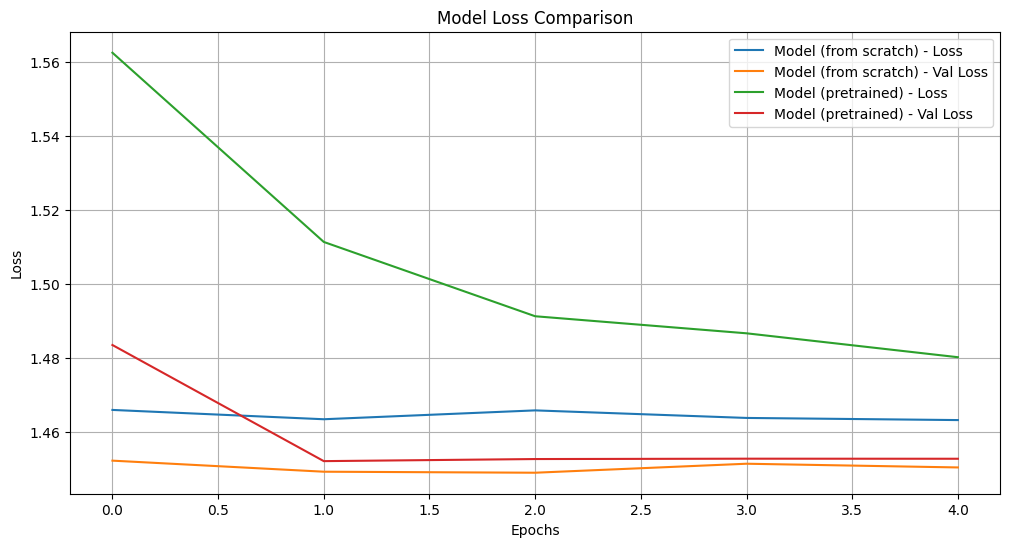

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(history_scratch.history['accuracy'], label='Model (from scratch) - Accuracy')
plt.plot(history_scratch.history['val_accuracy'], label='Model (from scratch) - Val Accuracy')

plt.plot(history_pretrained.history['accuracy'], label='Model (pretrained) - Accuracy')
plt.plot(history_pretrained.history['val_accuracy'], label='Model (pretrained) - Val Accuracy')

plt.title('Model Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='best')
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 6))

plt.plot(history_scratch.history['loss'], label='Model (from scratch) - Loss')
plt.plot(history_scratch.history['val_loss'], label='Model (from scratch) - Val Loss')

plt.plot(history_pretrained.history['loss'], label='Model (pretrained) - Loss')
plt.plot(history_pretrained.history['val_loss'], label='Model (pretrained) - Val Loss')

plt.title('Model Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='best')
plt.grid(True)
plt.show()
